In [399]:
#importando a biblioteca pandas
import pandas as pd


In [400]:

dados = pd.read_csv("/content/sample_data/A150850189_28_143_208.csv", encoding="ISO-8859-1", skiprows=3, sep=";", skipfooter=12, thousands=".", decimal=",", engine="python")


In [401]:
#Visualiza apenas as 5 primeiras: dados.head()
dados.head()


,Unidade da Federação,1992/Mar,1992/Abr,1993/Mai,1993/Dez,1994/Jan,1994/Fev,1994/Mai,1994/Ago,1994/Nov,...,2021/Jan,2021/Fev,2021/Mar,2021/Abr,2021/Mai,2021/Jun,2021/Jul,2021/Ago,2021/Set,Total
0,11 Rondônia,-,-,-,-,-,-,-,-,-,...,10045624.39,10677245.18,18147121.02,17753851.45,17659855.79,14435903.47,11834435.10,7371334.84,1682801.60,1088059702.25
1,12 Acre,-,-,-,-,-,-,-,-,-,...,4175526.06,5282655.42,5699597.78,5002272.59,4326882.24,3458187.11,2302711.01,1196754.85,-,475290315.34
2,13 Amazonas,-,-,-,-,-,-,-,-,-,...,27406458.57,22341042.63,27923786.94,24515920.09,23973537.71,22175398.40,21614943.55,13806958.66,5292323.36,2061943006.93
3,14 Roraima,-,-,-,-,-,-,-,-,-,...,3557821.99,4172285.82,5427226.70,4192540.54,3681417.80,3475205.55,3320807.96,2907871.07,1496814.75,352546288.71
4,15 Pará,-,-,-,-,-,-,-,-,-,...,39042349.46,37113440.70,49625416.13,52558327.29,50907226.77,43876590.47,33718084.12,20837865.89,4620263.03,4968811817.17


In [402]:
# traz as ultimas 5 linhas
dados.tail()

,Unidade da Federação,1992/Mar,1992/Abr,1993/Mai,1993/Dez,1994/Jan,1994/Fev,1994/Mai,1994/Ago,1994/Nov,...,2021/Jan,2021/Fev,2021/Mar,2021/Abr,2021/Mai,2021/Jun,2021/Jul,2021/Ago,2021/Set,Total
22,43 Rio Grande do Sul,-,-,-,-,-,-,-,-,-,...,115991861.17,126730284.94,169687680.33,145302546.19,155084262.06,142812283.70,112805351.92,74954589.62,25200345.68,13613341350.00
23,50 Mato Grosso do Sul,-,-,-,-,-,-,-,-,-,...,24727004.66,25600761.42,32506184.09,33101059.57,36885633.11,31595196.27,20711974.43,11302985.98,2445267.12,2516383489.01
24,51 Mato Grosso,-,-,-,-,-,-,-,-,-,...,18889711.53,21544594.04,35790837.70,37534015.20,37859473.58,34937134.14,29364200.76,19849249.43,7325067.61,2386584382.72
25,52 Goiás,-,-,-,-,-,-,-,-,-,...,42638703.48,45715467.93,74464062.86,68630407.92,69467332.76,67162348.93,57891285.60,44939821.34,18860370.17,5380179246.60
26,53 Distrito Federal,-,-,-,-,-,-,-,-,-,...,24484716.93,24156062.77,36391034.41,35641761.42,32434557.27,27196457.00,26265515.44,22156437.60,13173812.37,2778456616.77


In [403]:
# Apresenta a estrutura do conjunto de dados, permitindo identificar tipos de variáveis, volume de dados e possíveis inconsistências
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Columns: 293 entries, Unidade da Federação to Total
dtypes: float64(170), object(123)
memory usage: 61.9+ KB


In [404]:
# dados.mean(numeric_only=True) - Calcula a média das colunas numéricas, ignorando colunas de texto (object)

dados_numericos = dados.select_dtypes(include='number')  # Seleciona apenas as colunas numéricas
dados_numericos.mean()  # Calcula a média dessas colunas

,0
2007/Ago,304952.77
2007/Set,788145.26
2007/Out,2440162.96
2007/Nov,5517354.05
2007/Dez,12337159.42
...,...
2021/Mai,87271862.20
2021/Jun,77590406.47
2021/Jul,60846287.01
2021/Ago,43885716.30


In [405]:
# Padroniza a exibição de valores numéricos (float) com duas casas decimais, melhorando a legibilidade dos dados
pd.options.display.float_format = '{:.2f}'.format

In [406]:
dados_numericos.mean()

,0
2007/Ago,304952.77
2007/Set,788145.26
2007/Out,2440162.96
2007/Nov,5517354.05
2007/Dez,12337159.42
...,...
2021/Mai,87271862.20
2021/Jun,77590406.47
2021/Jul,60846287.01
2021/Ago,43885716.30


In [407]:
# desafio: Selecionar a coluna mais recente. Obs.: A ultima coluna é a Total, ignorar esta.
# iloc[linhas, colunas]. : → todas as linhas. [-2] → segunda coluna a partir do final. Pegue todas as linhas da penúltima coluna

dados.iloc[:, [-2]]

,2021/Set
0,1682801.60
1,-
2,5292323.36
3,1496814.75
4,4620263.03
5,626751.41
6,312354.68
7,11194657.20
8,9371428.06
9,16234603.93


In [408]:
dados["2008/Ago"].mean()

np.float64(26645398.35703704)

<Axes: xlabel='Unidade da Federação'>

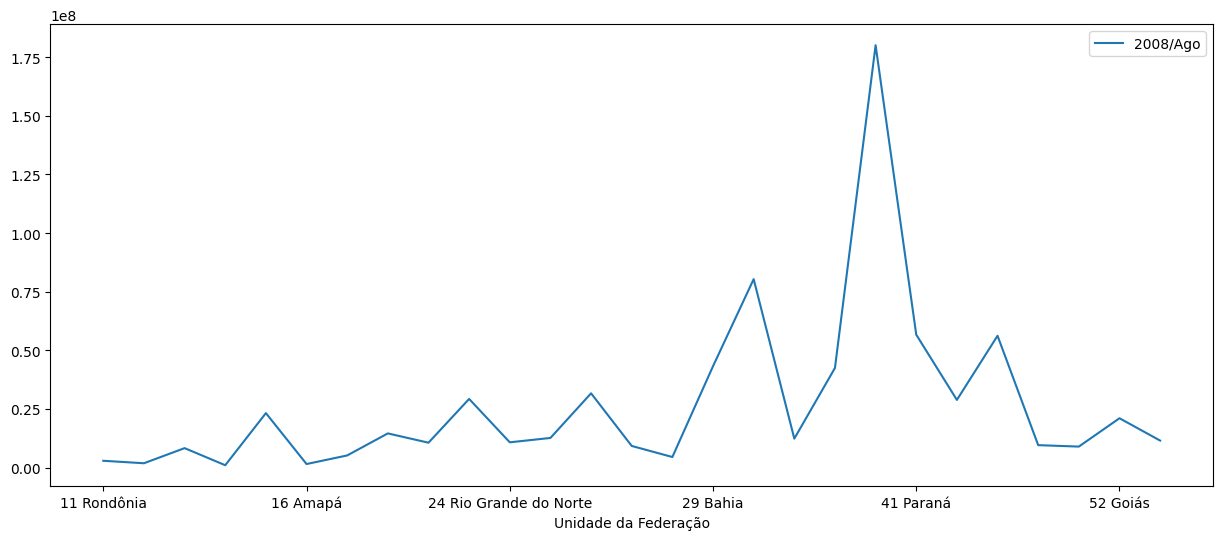

In [409]:
# Gera um gráfico relacionando os valores da coluna "2008/Ago" com as unidades da federação, permitindo a visualização comparativa entre os estados
dados.plot(x="Unidade da Federação", y="2008/Ago", figsize=(15,6))


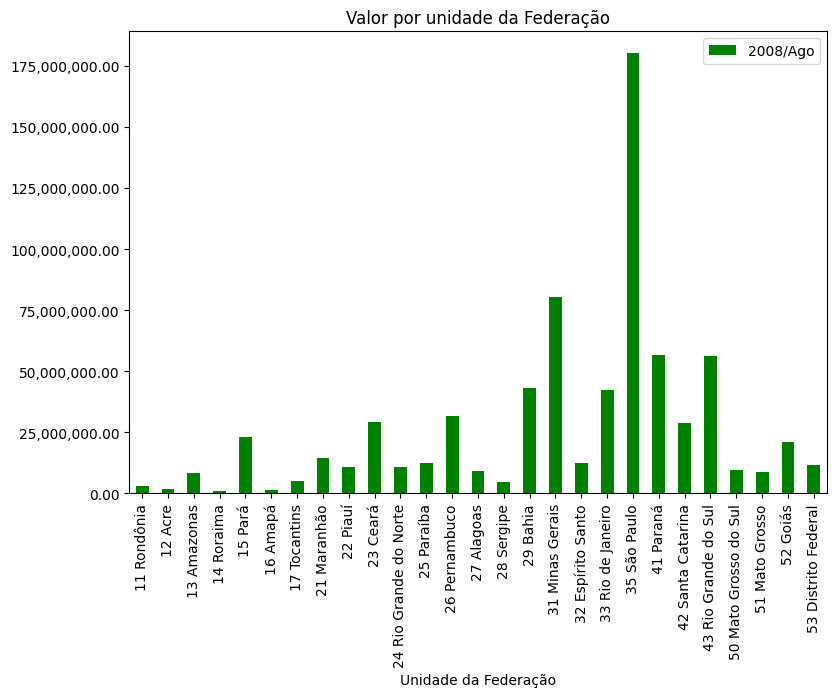

In [410]:
import matplotlib.pyplot as plt   # Biblioteca utilizada para criação de gráficos e visualizações de dados
import matplotlib.ticker as ticker  # Módulo utilizado para formatação dos valores exibidos nos eixos dos gráficos

# Definindo o gráfico de barras como forma de visualização, visando facilitar a comparação dos valores entre as unidades da federação
axis = dados.plot(x="Unidade da Federação",
                  y="2008/Ago",
                  kind="bar",
                  figsize=(9,6),
                  title="Valor por Unidade",
                  color="green")

axis.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.2f}'))

plt.title("Valor por unidade da Federação")
plt.show()


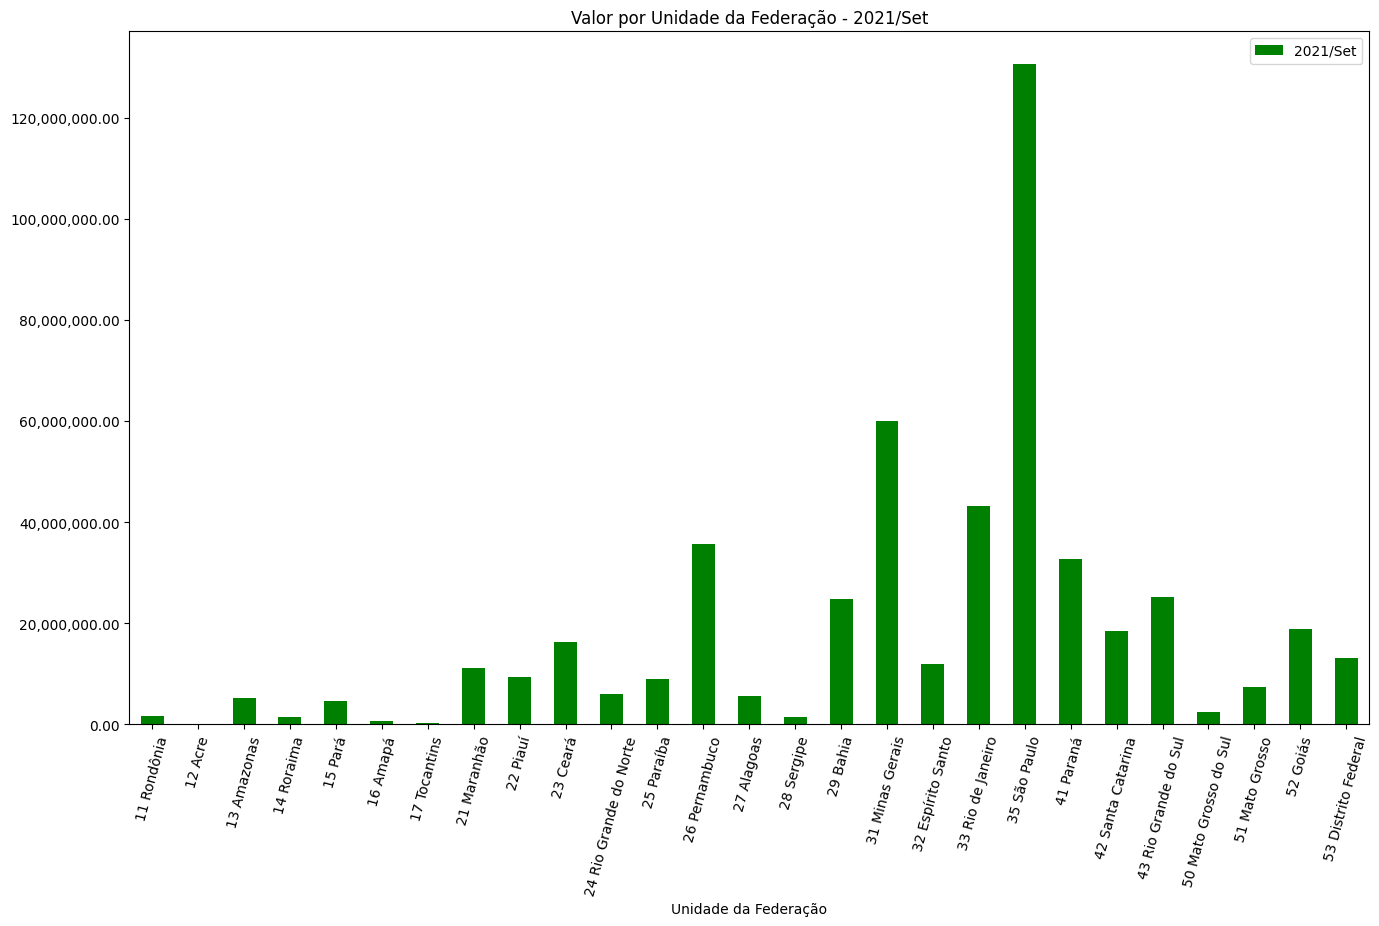

In [411]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import warnings

# Suprime avisos do pandas durante a execução do código
warnings.filterwarnings("ignore")

# Converte automaticamente colunas numéricas que estão como texto para o tipo adequado
dados = dados.apply(pd.to_numeric, errors="ignore")

# Identifica dinamicamente a coluna do mês mais recente, desconsiderando a coluna de total
coluna_recente = dados.columns[-2]

# Garante que a coluna selecionada seja numérica
dados[coluna_recente] = pd.to_numeric(dados[coluna_recente], errors="coerce")

# Ordena os dados do maior para o menor com base na coluna mais recente para melhorar a análise visual
#dados = dados.sort_values(by=coluna_recente, ascending=False)

# Definindo o gráfico de barras como forma de visualização, visando facilitar a comparação dos valores entre as unidades da federação
axis = dados.plot(
    x="Unidade da Federação",
    y=coluna_recente,
    kind="bar",
    figsize=(16,9),
    color="green"
)

# Define o título do gráfico com base no mês mais recente
axis.set_title(f"Valor por Unidade da Federação - {coluna_recente}")

# Formata os valores do eixo Y para melhor leitura
axis.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.2f}'))

# Rotaciona as legendas do eixo X em 45 graus para melhorar a legibilidade
plt.xticks(rotation=75)
plt.show()

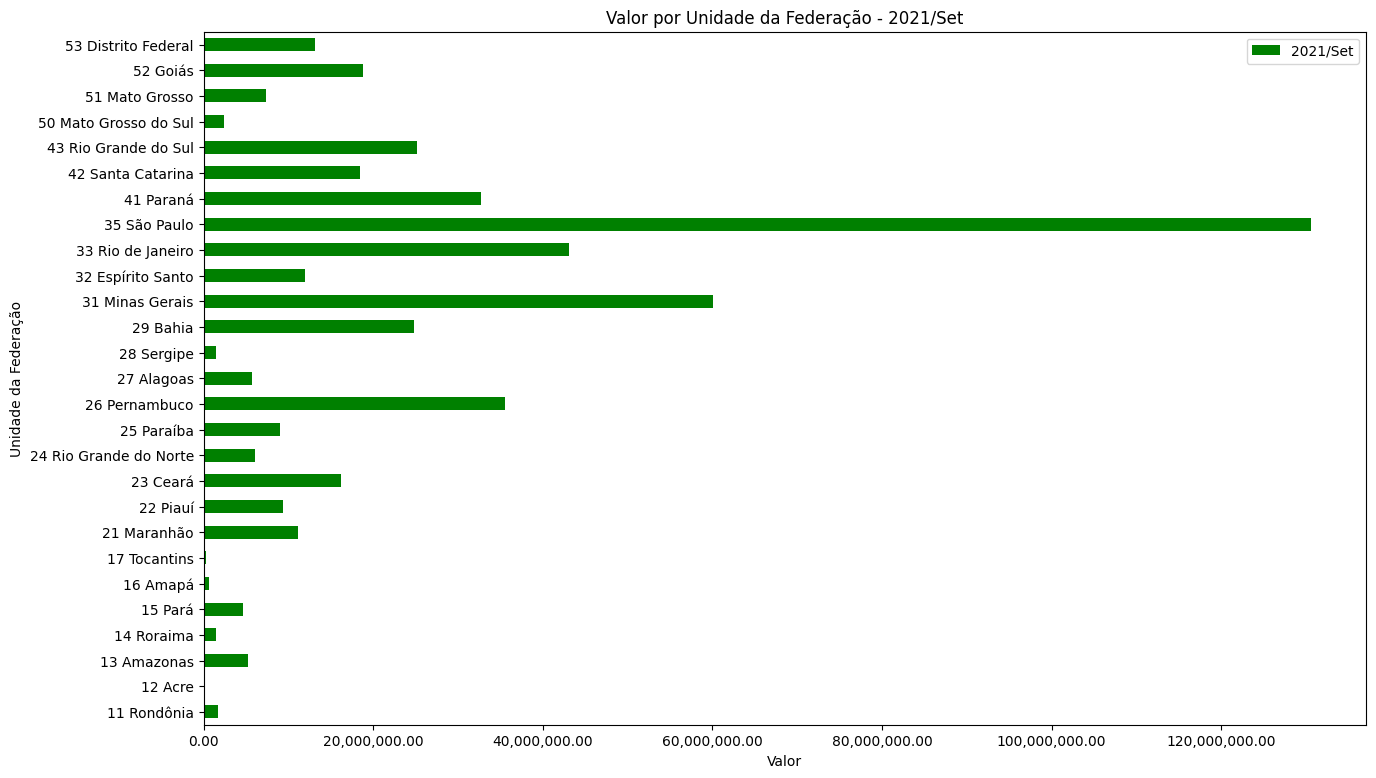

In [412]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import warnings

# Suprime avisos do pandas durante a execução do código
warnings.filterwarnings("ignore")

# Converte automaticamente colunas numéricas que estão como texto para o tipo adequado
dados = dados.apply(pd.to_numeric, errors="ignore")

# Identifica dinamicamente a coluna do mês mais recente, desconsiderando a coluna de total
coluna_recente = dados.columns[-2]

# Garante que a coluna selecionada seja numérica
dados[coluna_recente] = pd.to_numeric(dados[coluna_recente], errors="coerce")

# Ordena os dados do maior para o menor com base na coluna mais recente para melhorar a análise visual
#dados = dados.sort_values(by=coluna_recente, ascending=False)

# Definindo o gráfico de barras como forma de visualização, visando facilitar a comparação dos valores entre as unidades da federação
axis = dados.plot(
    x="Unidade da Federação",
    y=coluna_recente,
    kind="barh",
    figsize=(15,9),
    color="green"
)

# Define o título do gráfico com base no mês mais recente
axis.set_title(f"Valor por Unidade da Federação - {coluna_recente}")


# Formata os valores do eixo Y para melhor leitura
axis.xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.2f}'))

plt.xlabel("Valor")
plt.ylabel("Unidade da Federação")

# Rotaciona as legendas do eixo X em 45 graus para melhorar a legibilidade
plt.yticks(rotation=0)

plt.show()

Aula 3 - Análise exploratória de dados.
Manipulação de Dados

In [413]:
# Usa uma lista de colunas para selecionar várias colunas ao mesmo tempo: ["uma coluna"] retorna uma coluna, [["col1", "col2"]] retorna múltiplas colunas
dados[["2008/Ago", "2008/Set"]].head()

,2008/Ago,2008/Set
0,2938286.29,2843930.91
1,1886871.84,2084884.80
2,8331763.97,8148089.92
3,1045291.11,1003740.89
4,23259148.28,23667690.01


In [414]:
# existem periodo sem dados
dados.head()

,Unidade da Federação,1992/Mar,1992/Abr,1993/Mai,1993/Dez,1994/Jan,1994/Fev,1994/Mai,1994/Ago,1994/Nov,...,2021/Jan,2021/Fev,2021/Mar,2021/Abr,2021/Mai,2021/Jun,2021/Jul,2021/Ago,2021/Set,Total
0,11 Rondônia,-,-,-,-,-,-,-,-,-,...,10045624.39,10677245.18,18147121.02,17753851.45,17659855.79,14435903.47,11834435.10,7371334.84,1682801.60,1088059702.25
1,12 Acre,-,-,-,-,-,-,-,-,-,...,4175526.06,5282655.42,5699597.78,5002272.59,4326882.24,3458187.11,2302711.01,1196754.85,NaN,475290315.34
2,13 Amazonas,-,-,-,-,-,-,-,-,-,...,27406458.57,22341042.63,27923786.94,24515920.09,23973537.71,22175398.40,21614943.55,13806958.66,5292323.36,2061943006.93
3,14 Roraima,-,-,-,-,-,-,-,-,-,...,3557821.99,4172285.82,5427226.70,4192540.54,3681417.80,3475205.55,3320807.96,2907871.07,1496814.75,352546288.71
4,15 Pará,-,-,-,-,-,-,-,-,-,...,39042349.46,37113440.70,49625416.13,52558327.29,50907226.77,43876590.47,33718084.12,20837865.89,4620263.03,4968811817.17


In [415]:
dados.columns

Index(['Unidade da Federação', '1992/Mar', '1992/Abr', '1993/Mai', '1993/Dez',
       '1994/Jan', '1994/Fev', '1994/Mai', '1994/Ago', '1994/Nov',
       ...
       '2021/Jan', '2021/Fev', '2021/Mar', '2021/Abr', '2021/Mai', '2021/Jun',
       '2021/Jul', '2021/Ago', '2021/Set', 'Total'],
      dtype='object', length=293)

In [416]:
dados_numericos.mean()

,0
2007/Ago,304952.77
2007/Set,788145.26
2007/Out,2440162.96
2007/Nov,5517354.05
2007/Dez,12337159.42
...,...
2021/Mai,87271862.20
2021/Jun,77590406.47
2021/Jul,60846287.01
2021/Ago,43885716.30


In [417]:
# Retorna os nomes das colunas que possuem dados numéricos, ignorando colunas vazias
coluna_usaveis = dados_numericos.mean().index.tolist()
# Adiciona a coluna de identificação (estado) no início da lista para manter referência dos dados
coluna_usaveis.insert(0, "Unidade da Federação")
# Exibe as 5 primeiras colunas da lista para conferência rápida
coluna_usaveis[:5]

['Unidade da Federação', '2007/Ago', '2007/Set', '2007/Out', '2007/Nov']

In [418]:
dados_usaveis = dados[coluna_usaveis]
dados_usaveis.head()

,Unidade da Federação,2007/Ago,2007/Set,2007/Out,2007/Nov,2007/Dez,2008/Jan,2008/Fev,2008/Mar,2008/Abr,...,2020/Dez,2021/Jan,2021/Fev,2021/Mar,2021/Abr,2021/Mai,2021/Jun,2021/Jul,2021/Ago,Total
0,11 Rondônia,4209.37,16397.03,133645.19,346912.84,711758.31,1829559.71,1940792.63,1955721.68,2143353.81,...,9469279.43,10045624.39,10677245.18,18147121.02,17753851.45,17659855.79,14435903.47,11834435.10,7371334.84,1088059702.25
1,12 Acre,10470.07,14001.71,86200.85,301323.68,769612.36,1731744.62,1743978.66,2057439.02,2057829.69,...,3820865.83,4175526.06,5282655.42,5699597.78,5002272.59,4326882.24,3458187.11,2302711.01,1196754.85,475290315.34
2,13 Amazonas,35752.72,45570.64,416012.30,2020381.79,5949408.99,11419210.08,7934652.10,8641517.13,8531576.49,...,21911210.94,27406458.57,22341042.63,27923786.94,24515920.09,23973537.71,22175398.40,21614943.55,13806958.66,2061943006.93
3,14 Roraima,4785.91,11858.63,43852.67,369328.51,470676.43,808448.39,771687.83,876091.18,896952.53,...,3193708.89,3557821.99,4172285.82,5427226.70,4192540.54,3681417.80,3475205.55,3320807.96,2907871.07,352546288.71
4,15 Pará,181159.29,433414.74,1893197.50,5105406.44,13162823.43,21762104.16,20126081.01,22149375.82,23436682.75,...,37925512.28,39042349.46,37113440.70,49625416.13,52558327.29,50907226.77,43876590.47,33718084.12,20837865.89,4968811817.17


In [419]:
# Define a coluna "Unidade da Federação" como índice do DataFrame para melhor organização dos dados
dados_usaveis = dados_usaveis.set_index("Unidade da Federação")
dados_usaveis.head()

,2007/Ago,2007/Set,2007/Out,2007/Nov,2007/Dez,2008/Jan,2008/Fev,2008/Mar,2008/Abr,2008/Mai,...,2020/Dez,2021/Jan,2021/Fev,2021/Mar,2021/Abr,2021/Mai,2021/Jun,2021/Jul,2021/Ago,Total
Unidade da Federação,,,,,,,,,,,,,,,,,,,,,
11 Rondônia,4209.37,16397.03,133645.19,346912.84,711758.31,1829559.71,1940792.63,1955721.68,2143353.81,2280382.58,...,9469279.43,10045624.39,10677245.18,18147121.02,17753851.45,17659855.79,14435903.47,11834435.10,7371334.84,1088059702.25
12 Acre,10470.07,14001.71,86200.85,301323.68,769612.36,1731744.62,1743978.66,2057439.02,2057829.69,2226577.93,...,3820865.83,4175526.06,5282655.42,5699597.78,5002272.59,4326882.24,3458187.11,2302711.01,1196754.85,475290315.34
13 Amazonas,35752.72,45570.64,416012.30,2020381.79,5949408.99,11419210.08,7934652.10,8641517.13,8531576.49,9079902.15,...,21911210.94,27406458.57,22341042.63,27923786.94,24515920.09,23973537.71,22175398.40,21614943.55,13806958.66,2061943006.93
14 Roraima,4785.91,11858.63,43852.67,369328.51,470676.43,808448.39,771687.83,876091.18,896952.53,1027288.73,...,3193708.89,3557821.99,4172285.82,5427226.70,4192540.54,3681417.80,3475205.55,3320807.96,2907871.07,352546288.71
15 Pará,181159.29,433414.74,1893197.50,5105406.44,13162823.43,21762104.16,20126081.01,22149375.82,23436682.75,23861080.80,...,37925512.28,39042349.46,37113440.70,49625416.13,52558327.29,50907226.77,43876590.47,33718084.12,20837865.89,4968811817.17


In [420]:
dados_usaveis["2019/Ago"].head()

,2019/Ago
Unidade da Federação,
11 Rondônia,8909111.89
12 Acre,2981072.98
13 Amazonas,16493719.52
14 Roraima,3181321.82
15 Pará,36462011.47


In [421]:
# Localiza uma linha pelo índice
dados_usaveis.loc["12 Acre"]

,12 Acre
2007/Ago,10470.07
2007/Set,14001.71
2007/Out,86200.85
2007/Nov,301323.68
2007/Dez,769612.36
...,...
2021/Mai,4326882.24
2021/Jun,3458187.11
2021/Jul,2302711.01
2021/Ago,1196754.85


In [422]:
# Localiza uma linha pela posição (índice numérico), retornando os dados da segunda linha do DataFrame
dados_usaveis.iloc[1]

,12 Acre
2007/Ago,10470.07
2007/Set,14001.71
2007/Out,86200.85
2007/Nov,301323.68
2007/Dez,769612.36
...,...
2021/Mai,4326882.24
2021/Jun,3458187.11
2021/Jul,2302711.01
2021/Ago,1196754.85


<Axes: xlabel='Unidade da Federação'>

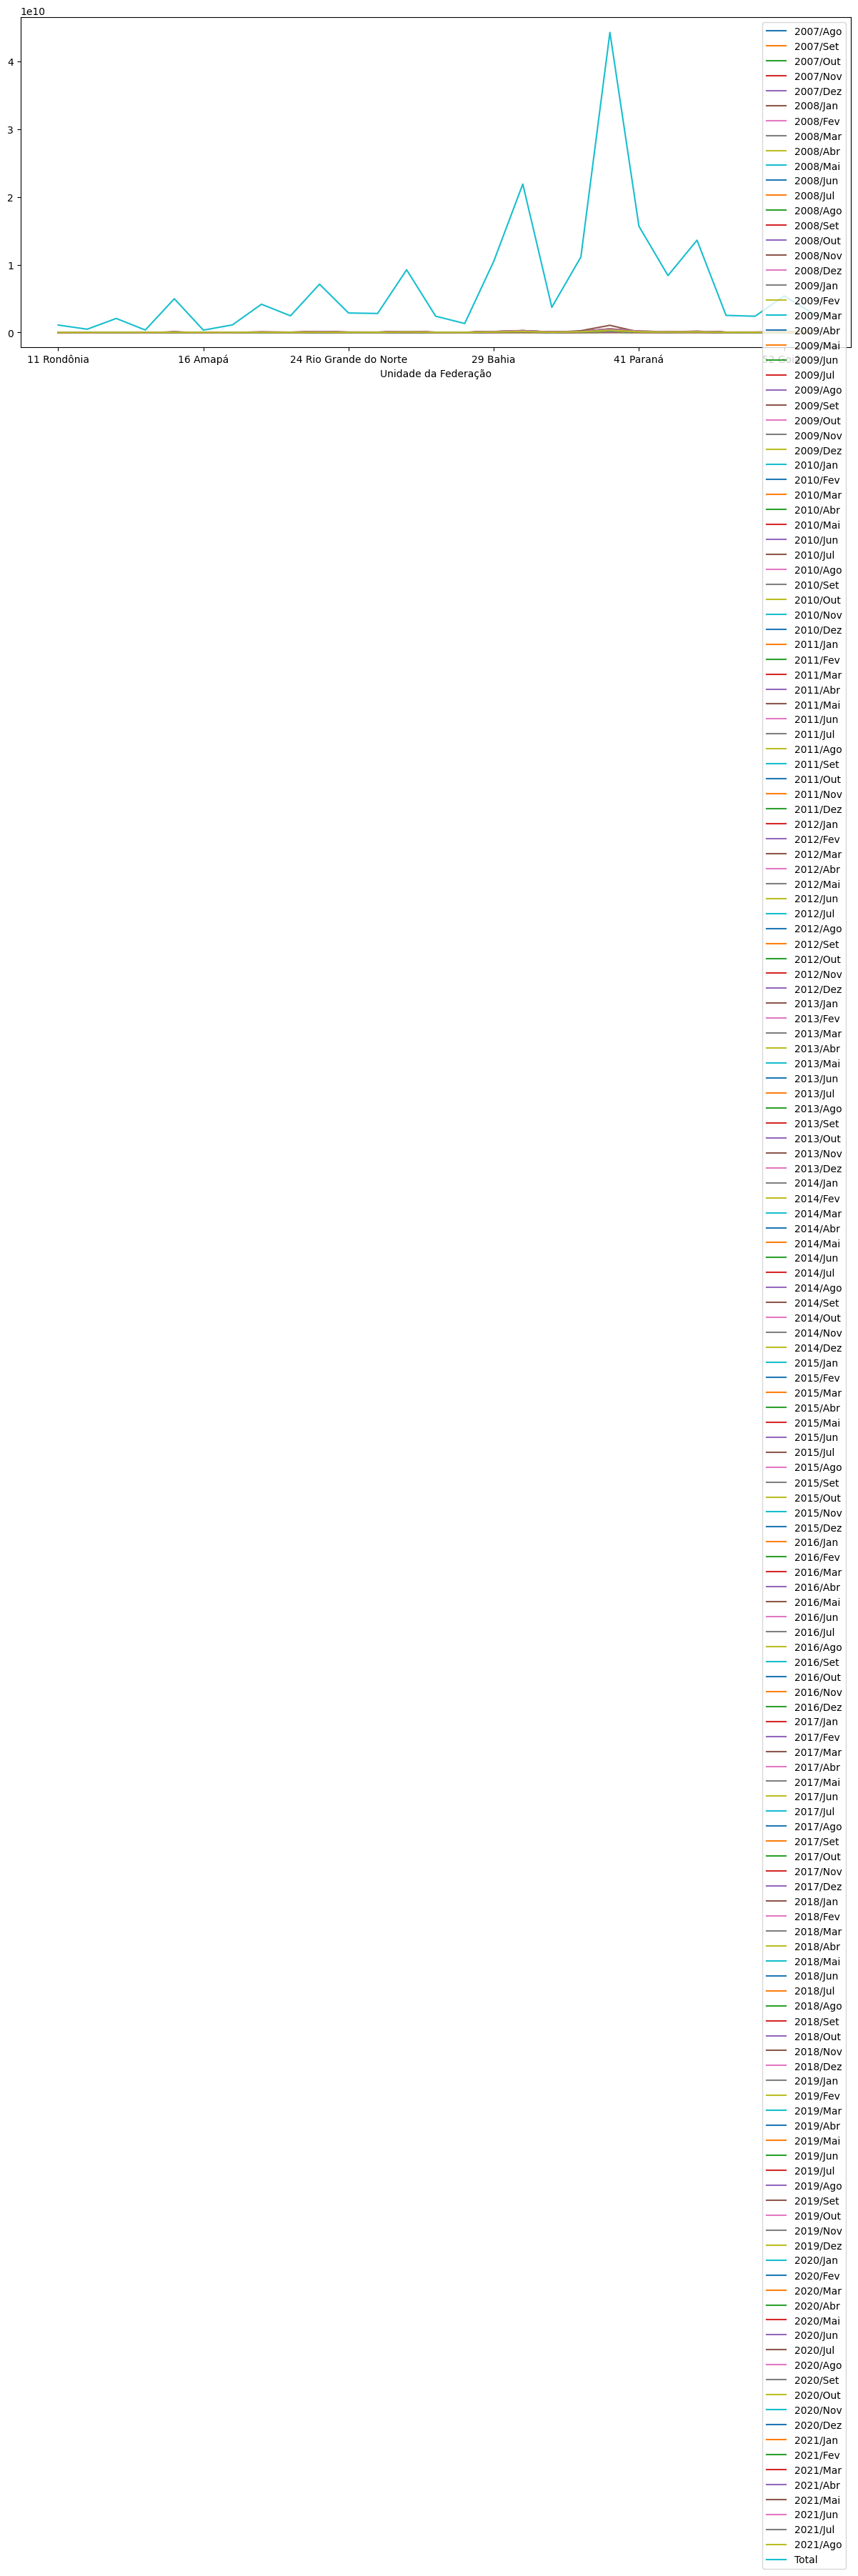

In [423]:
dados_usaveis.plot(figsize=(15,6))

In [424]:
# Transpõe o DataFrame (troca linhas por colunas) e exibe as primeiras linhas para visualização
dados_usaveis.T.head()

Unidade da Federação,11 Rondônia,12 Acre,13 Amazonas,14 Roraima,15 Pará,16 Amapá,17 Tocantins,21 Maranhão,22 Piauí,23 Ceará,...,32 Espírito Santo,33 Rio de Janeiro,35 São Paulo,41 Paraná,42 Santa Catarina,43 Rio Grande do Sul,50 Mato Grosso do Sul,51 Mato Grosso,52 Goiás,53 Distrito Federal
2007/Ago,4209.37,10470.07,35752.72,4785.91,181159.29,33672.74,4113.76,385330.18,220788.25,357904.65,...,57408.11,469469.34,1665349.90,554800.22,693955.05,1049252.33,199556.12,63562.50,179395.82,191951.47
2007/Set,16397.03,14001.71,45570.64,11858.63,433414.74,104822.98,76633.06,1018352.93,353468.67,572356.18,...,284224.80,921646.57,4434168.64,1431708.01,1092964.12,3182913.14,573675.41,232444.62,418053.58,769966.25
2007/Out,133645.19,86200.85,416012.30,43852.67,1893197.50,118378.28,343702.61,2277717.78,1078182.68,1865065.71,...,1152115.25,2994664.57,14577395.84,4630402.44,3562300.82,8571312.11,1069816.66,927219.59,1198730.25,2165619.56
2007/Nov,346912.84,301323.68,2020381.79,369328.51,5105406.44,226661.18,1068685.94,4334468.23,2406035.32,5131814.39,...,2296383.23,7250528.08,35032259.98,11120030.79,7578502.38,16592432.80,1995899.52,1740439.60,2712117.54,3813256.48
2007/Dez,711758.31,769612.36,5949408.99,470676.43,13162823.43,844019.90,3022200.87,8832514.85,4929772.93,10798042.86,...,5724199.54,13627123.27,76668547.41,28790722.87,14772555.10,30134255.70,4277979.14,5394225.43,9293914.78,7121965.42


<Axes: >

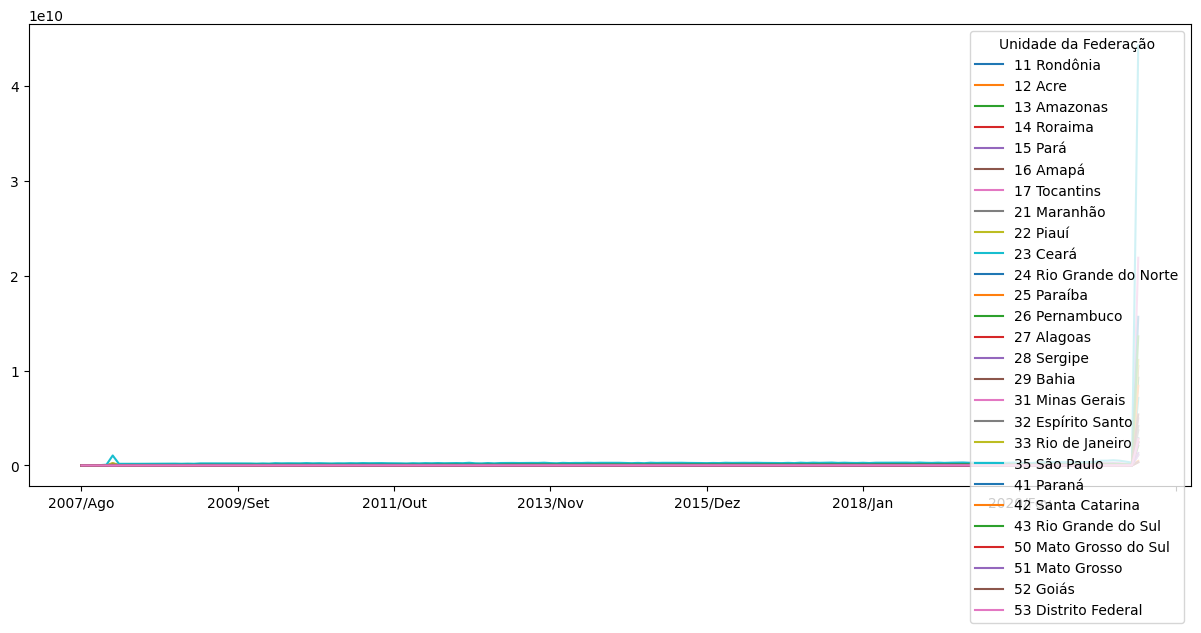

In [425]:
dados_usaveis.T.plot(figsize=(15,6))
# Grafico ainda apresenta má vizualização (14:52 no video)

In [426]:
# Exibe as últimas linhas do DataFrame transposto, desconsiderando a coluna "Total" que não é relevante neste contexto
dados_usaveis.T.tail()

Unidade da Federação,11 Rondônia,12 Acre,13 Amazonas,14 Roraima,15 Pará,16 Amapá,17 Tocantins,21 Maranhão,22 Piauí,23 Ceará,...,32 Espírito Santo,33 Rio de Janeiro,35 São Paulo,41 Paraná,42 Santa Catarina,43 Rio Grande do Sul,50 Mato Grosso do Sul,51 Mato Grosso,52 Goiás,53 Distrito Federal
2021/Mai,17659855.79,4326882.24,23973537.71,3681417.80,50907226.77,5672086.52,10161783.68,55324683.42,32550777.47,102825954.51,...,57345370.07,145372684.38,548112705.83,191861617.22,101661537.37,155084262.06,36885633.11,37859473.58,69467332.76,32434557.27
2021/Jun,14435903.47,3458187.11,22175398.40,3475205.55,43876590.47,5469150.38,6349488.16,51958573.27,26015797.57,81919446.05,...,48137665.89,124909043.81,503160959.54,163580936.16,93055772.86,142812283.70,31595196.27,34937134.14,67162348.93,27196457.00
2021/Jul,11834435.10,2302711.01,21614943.55,3320807.96,33718084.12,4136950.62,4610170.61,37775425.78,19972846.10,57727138.38,...,36550871.52,113660882.20,404373175.61,119408026.56,70531971.21,112805351.92,20711974.43,29364200.76,57891285.60,26265515.44
2021/Ago,7371334.84,1196754.85,13806958.66,2907871.07,20837865.89,1875241.91,2304080.49,25779674.83,15220885.72,35650007.47,...,27127454.08,94137361.39,301986341.98,91187722.64,48884998.15,74954589.62,11302985.98,19849249.43,44939821.34,22156437.60
Total,1088059702.25,475290315.34,2061943006.93,352546288.71,4968811817.17,337181964.14,1110344733.46,4161325769.23,2450508593.82,7118540187.61,...,3710941856.86,11131868548.73,44290790025.14,15672157558.11,8392938841.37,13613341350.00,2516383489.01,2386584382.72,5380179246.60,2778456616.77


In [427]:
# Remove a coluna "Total" do DataFrame, pois não é relevante para a análise
dados_usaveis = dados_usaveis.drop("Total", axis=1)
dados_usaveis.head()

,2007/Ago,2007/Set,2007/Out,2007/Nov,2007/Dez,2008/Jan,2008/Fev,2008/Mar,2008/Abr,2008/Mai,...,2020/Nov,2020/Dez,2021/Jan,2021/Fev,2021/Mar,2021/Abr,2021/Mai,2021/Jun,2021/Jul,2021/Ago
Unidade da Federação,,,,,,,,,,,,,,,,,,,,,
11 Rondônia,4209.37,16397.03,133645.19,346912.84,711758.31,1829559.71,1940792.63,1955721.68,2143353.81,2280382.58,...,8909539.74,9469279.43,10045624.39,10677245.18,18147121.02,17753851.45,17659855.79,14435903.47,11834435.10,7371334.84
12 Acre,10470.07,14001.71,86200.85,301323.68,769612.36,1731744.62,1743978.66,2057439.02,2057829.69,2226577.93,...,3497348.48,3820865.83,4175526.06,5282655.42,5699597.78,5002272.59,4326882.24,3458187.11,2302711.01,1196754.85
13 Amazonas,35752.72,45570.64,416012.30,2020381.79,5949408.99,11419210.08,7934652.10,8641517.13,8531576.49,9079902.15,...,20587412.38,21911210.94,27406458.57,22341042.63,27923786.94,24515920.09,23973537.71,22175398.40,21614943.55,13806958.66
14 Roraima,4785.91,11858.63,43852.67,369328.51,470676.43,808448.39,771687.83,876091.18,896952.53,1027288.73,...,3531874.44,3193708.89,3557821.99,4172285.82,5427226.70,4192540.54,3681417.80,3475205.55,3320807.96,2907871.07
15 Pará,181159.29,433414.74,1893197.50,5105406.44,13162823.43,21762104.16,20126081.01,22149375.82,23436682.75,23861080.80,...,37228236.49,37925512.28,39042349.46,37113440.70,49625416.13,52558327.29,50907226.77,43876590.47,33718084.12,20837865.89


<Axes: >

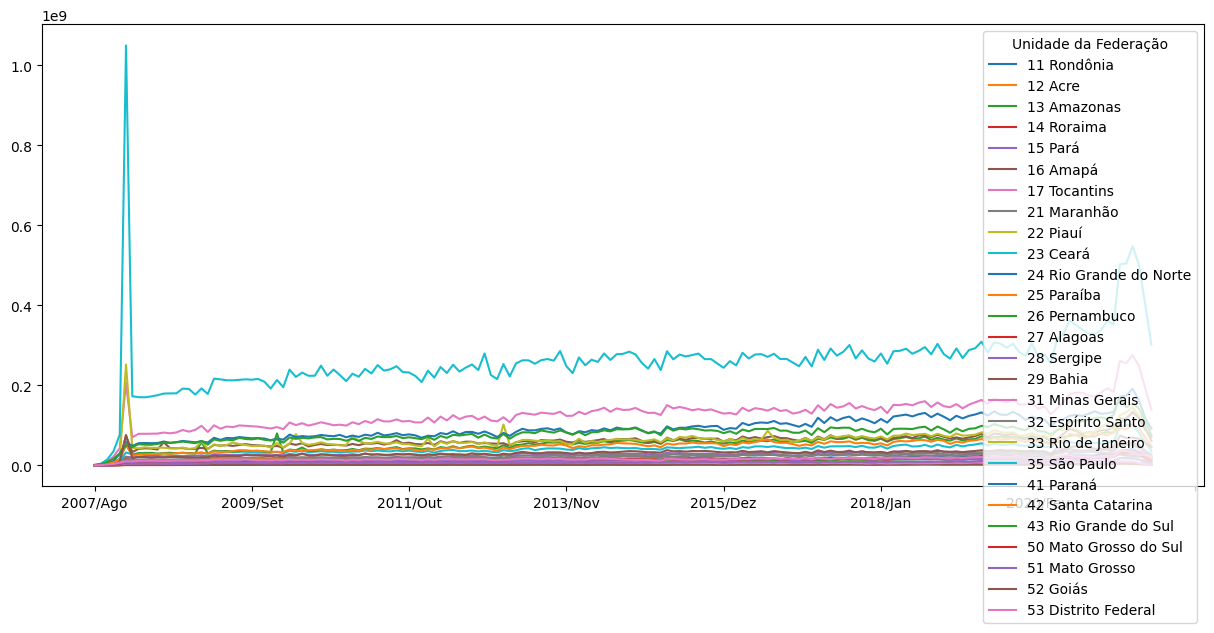

In [429]:
# Transpõe o DataFrame e gera um gráfico de linhas para visualizar a evolução dos valores ao longo do tempo
dados_usaveis.T.plot(figsize=(15,6))

In [432]:
# Retorna o valor máximo de cada coluna após a transposição, indicando o maior valor de cada estado ao longo do tempo
dados_usaveis.T.max()

,0
Unidade da Federação,
11 Rondônia,18147121.02
12 Acre,5699597.78
13 Amazonas,27923786.94
14 Roraima,5427226.70
15 Pará,52558327.29
16 Amapá,5672086.52
17 Tocantins,10161783.68
21 Maranhão,55324683.42
22 Piauí,32550777.47


<Axes: >

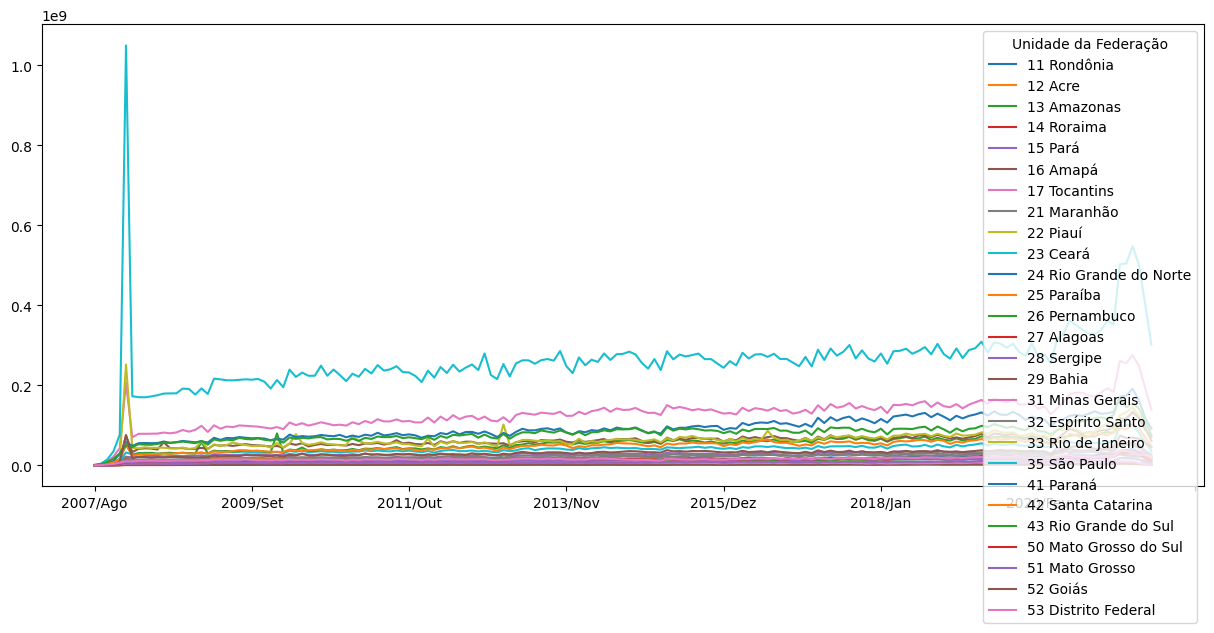

In [437]:
# Desafio I: reposicionar a legenda do Grafico.
# Desafio II: Retocar titulo de vizualização
# Desafio III: Incluir titulo nos eixos X e Y

dados_usaveis.T.plot(figsize=(15,6))

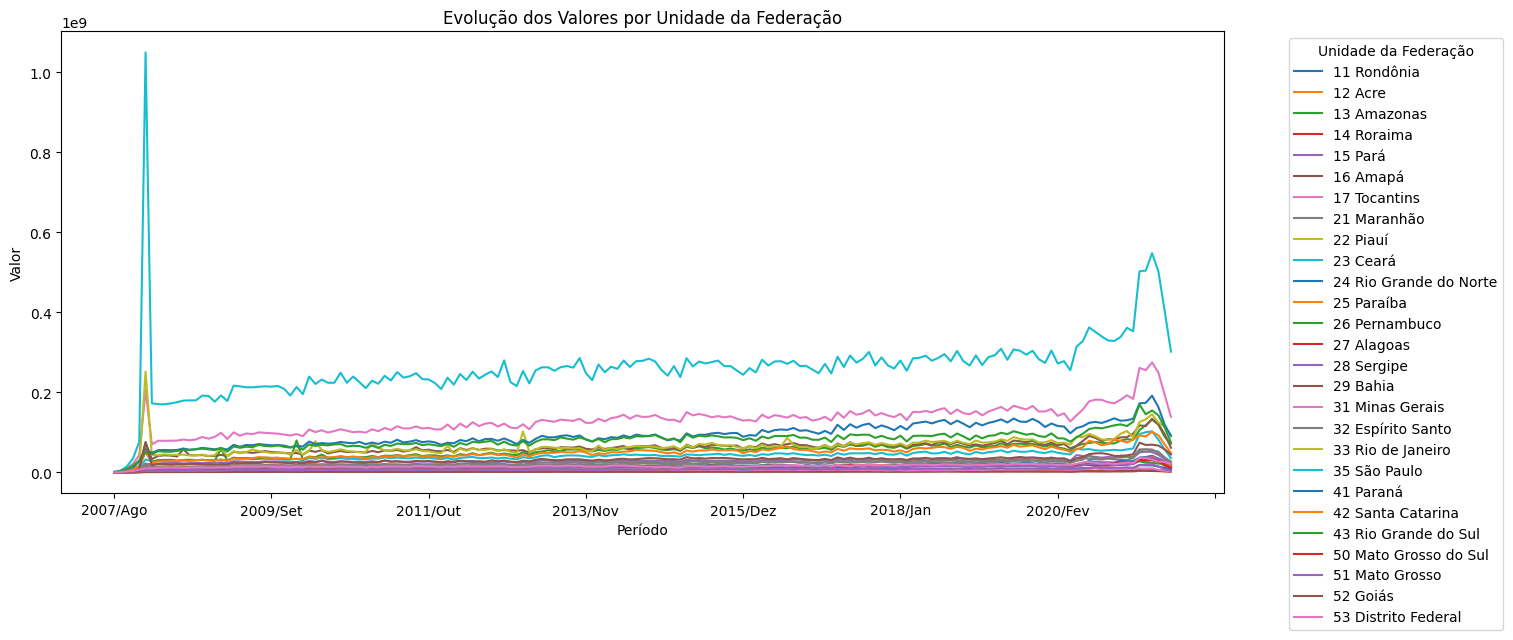

In [439]:
axis = dados_usaveis.T.plot(figsize=(15,6))

# Define o título do gráfico
axis.set_title("Evolução dos Valores por Unidade da Federação")

# Define os títulos dos eixos
axis.set_xlabel("Período")
axis.set_ylabel("Valor")

# Reposiciona a legenda para fora do gráfico
plt.legend(
    title="Unidade da Federação",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.show()